<a href="https://colab.research.google.com/github/opendatas2017/NMC/blob/main/NMCourse_sl_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# СЛАУ


In [ ]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from scipy.linalg import lu
import time
from scipy.linalg import hilbert
print("Numpy version is ",np.__version__)  # Должно показать версию, например 2.0.2

print("Python version is ",sys.version)

Numpy version is  2.0.2
Python version is  3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


## Решение систем линейных уравнений: LU-разложение с выбором ведущего элемента

Прямое решение системы $Ax = b$ через обращение матрицы ($x = A^{-1}b$) численно неустойчиво и дорого.
Стандартный промышленный подход — **LU-разложение с частичным выбором ведущего элемента**.

**Идея:**
$$ PA = LU $$
где:
- $P$ — матрица перестановок (меняет строки местами для устойчивости),
- $L$ — нижняя треугольная (единичная диагональ),
- $U$ — верхняя треугольная.

**Зачем два этапа (`factor` + `solve`)?**
Если нужно решить систему с **одной и той же матрицей $A$**, но разными векторами $b$ (например, в каждом шаге по времени), LU-разложение выполняется **один раз**, а подстановка — многократно. Это экономит вычисления ($O(n^3)$ против $O(n^2)$).

**Особенность примера:** Элемент $A_{0,0} = 0.001$ мал. Без перестановки строк (pivoting) это привело бы к большим числам и потере точности. SciPy автоматически выполнит перестановку.

In [ ]:
# ==============================================================================
# 📦 ИМПОРТЫ И НАСТРОЙКИ
# ==============================================================================
import numpy as np
from scipy.linalg import lu_factor, lu_solve, lu

# ==============================================================================
# 1️⃣ ПОДГОТОВКА ДАННЫХ: "Хитрая" матрица
# ==============================================================================
# Обратите внимание на элемент A[0,0] = 0.001.
# Без выбора ведущего элемента (pivoting) это могло бы привести к неустойчивости.
A = np.array([[0.001, 1.0, 0.0],
              [1.0,   2.0, 3.0],
              [4.0,   5.0, 6.0]], dtype=float)

b = np.array([1.0, 2.0, 3.0])
with np.printoptions(suppress=True, precision=6):
  print("🔍 Исходная матрица A:")
  print(A)
  print(f"\n⚠️ Обратите внимание: A[0,0] = {A[0,0]} (малый элемент)")

# ==============================================================================
# 2️⃣ LU-РАЗЛОЖЕНИЕ (Этап факторизации)
# ==============================================================================
# lu_factor возвращает сжатое представление:
# 1. Matrix LU (верхняя треугольная часть -> U, нижняя -> L)
# 2. Pivot (вектор перестановок строк)
lu_scipy, piv_scipy = lu_factor(A)

# ==============================================================================
# 3️⃣ РЕШЕНИЕ СИСТЕМЫ (Этап подстановки)
# ==============================================================================
# Используем разложение для быстрого решения Ax = b
x_scipy = lu_solve((lu_scipy, piv_scipy), b)

# ==============================================================================
# 4️⃣ ПРОВЕРКА И ВЕРИФИКАЦИЯ
# ==============================================================================
# Вычисляем невязку: ||Ax - b||
residual = np.linalg.norm(A @ x_scipy - b)

print("\n🚀 РЕЗУЛЬТАТЫ РЕШЕНИЯ")
print("=" * 50)
print(f"Найденное решение x: {x_scipy}")
print(f"Норма невязки ||Ax - b||: {residual:.2e}")
print(f"Статус: {'✅ Точно' if residual < 1e-10 else '❌ Большая ошибка'}")

# ==============================================================================
# 5️⃣ ВИЗУАЛИЗАЦИЯ РАЗЛОЖЕНИЯ (Для понимания механики)
# ==============================================================================
# Для учебных целей развернем сжатый формат в явные матрицы P, L, U
P, L, U = lu(A)
with np.printoptions(suppress=True, precision=6):
  print("\n🧩 СТРУКТУРА LU-РАЗЛОЖЕНИЯ (PA = LU):")
  print("Матрица перестановок P (строки были swapped):")
  print(P.astype(int))
  print("\nНижняя треугольная L:")
  print(np.round(L, 3))
  print("\nВерхняя треугольная U:")
  print(np.round(U, 3))



🔍 Исходная матрица A:
[[0.001 1.    0.   ]
 [1.    2.    3.   ]
 [4.    5.    6.   ]]

⚠️ Обратите внимание: A[0,0] = 0.001 (малый элемент)

🚀 РЕЗУЛЬТАТЫ РЕШЕНИЯ
Найденное решение x: [-1.00050025  1.0010005   0.33283308]
Норма невязки ||Ax - b||: 1.11e-16
Статус: ✅ Точно

🧩 СТРУКТУРА LU-РАЗЛОЖЕНИЯ (PA = LU):
Матрица перестановок P (строки были swapped):
[[0 1 0]
 [0 0 1]
 [1 0 0]]

Нижняя треугольная L:
[[1.    0.    0.   ]
 [0.    1.    0.   ]
 [0.25  0.751 1.   ]]

Верхняя треугольная U:
[[ 4.     5.     6.   ]
 [ 0.     0.999 -0.002]
 [ 0.     0.     1.501]]


Посмотрим как получить информацию о компонентах PLU  разложения матрицы

In [ ]:
import scipy
p, l, u = scipy.linalg.lu(A)
np.allclose(A, p @ l @ u)

True

In [ ]:
from scipy.linalg import solve
x = solve(A, b)
print(x)

[-1.00050025  1.0010005   0.33283308]


### 📝 Ключевые выводы по LU-разложению

1.  **Важность перестановок (Pivoting):**
    *   В матрице перестановок $P$ вы увидите, что строки были поменяны местами.
    *   Это сделано для того, чтобы избежать деления на малый элемент `0.001`. Алгоритм поставил на диагональ наибольший элемент из столбца (например, 4.0).
    *   Без этого ошибка округления могла бы вырасти в тысячи раз.

2.  **Эффективность:**
    *   `lu_factor` стоит $O(n^3)$ (дорого).
    *   `lu_solve` стоит $O(n^2)$ (дешево).
    *   **Правило:** Если нужно решить систему с одной матрицей $A$ для 100 разных векторов $b$, делайте `lu_factor` один раз, а `lu_solve` вызывайте в цикле.

3.  **Точность:**
    *   Невязка $||Ax - b||$ имеет порядок $10^{-15}$ (машинная точность). Это подтверждает устойчивость метода даже для плохо обусловленных матриц.

4.  **Сравнение с `np.linalg.solve`:**
    *   `np.linalg.solve` внутри тоже использует LU-разложение (через LAPACK), но сразу возвращает ответ.
    *   `scipy.linalg.lu_factor` + `lu_solve` дает контроль над процессом и выгоду при многократном решении.


### Разложение Холецкого для симметричных положительно определённых матриц

**Разложение Холецкого** — это специализированный метод для матриц, которые являются:
1.  **Симметричными** ($A = A^T$)
2.  **Положительно определёнными** (все собственные значения $\lambda_i > 0$)

**Формула:**
$$ A = L \cdot L^T $$
где $L$ — нижняя треугольная матрица.

**Преимущества перед LU-разложением:**
| Характеристика | LU-разложение | Холецкий |
|----------------|---------------|----------|
| **Тип матрицы** | Любая квадратная | Симметричная + положительно определённая |
| **Скорость** | $O(n^3)$ | $\approx \frac{1}{2} O(n^3)$ (в 2 раза быстрее) |
| **Память** | Хранит L и U | Хранит только L |
| **Устойчивость** | Требует перестановок (P) | Всегда устойчив без перестановок |



In [ ]:
# ==============================================================================
# 📦 ИМПОРТЫ И НАСТРОЙКИ
# ==============================================================================
import numpy as np
from scipy.linalg import cholesky

# 🎨 Настройка вывода: убираем научную нотацию (e-03, e+00)
np.set_printoptions(suppress=True, precision=6, linewidth=100)

# ==============================================================================
# 1️⃣ ПОДГОТОВКА ДАННЫХ: Ковариационная матрица
# ==============================================================================
# Симметричная положительно определённая матрица (типичный пример — ковариация)
A = np.array([[4.0, 2.0, 1.0],
              [2.0, 5.0, 2.0],
              [1.0, 2.0, 6.0]])

print("🔍 ИСХОДНАЯ МАТРИЦА A:")
print(A)

# ==============================================================================
# 2️⃣ ПРОВЕРКА УСЛОВИЙ ПРИМЕНИМОСТИ
# ==============================================================================
# Холецкий работает ТОЛЬКО для симметричных положительно определённых матриц
is_symmetric = np.allclose(A, A.T)
eigenvalues = np.linalg.eigvalsh(A)  # eigvalsh для симметричных матриц
is_pos_def = np.all(eigenvalues > 0)

print("\n✅ ПРОВЕРКА УСЛОВИЙ:")
print(f"   Симметрична (A = Aᵀ): {is_symmetric}")
print(f"   Собственные значения: {eigenvalues}")
print(f"   Положительно определена (λᵢ > 0): {is_pos_def}")

if not (is_symmetric and is_pos_def):
    raise ValueError("Матрица не подходит для разложения Холецкого!")

# ==============================================================================
# 3️⃣ РАЗЛОЖЕНИЕ ХОЛЕЦКОГО: A = L · Lᵀ
# ==============================================================================
# lower=True возвращает нижнюю треугольную матрицу L
# lower=False вернул бы верхнюю U, где A = Uᵀ · U
L = cholesky(A, lower=True)

print("\n🧩 РАЗЛОЖЕНИЕ ХОЛЕЦКОГО:")
print("   Нижняя треугольная матрица L:")
print(L)
print("\n   Верхняя треугольная матрица Lᵀ:")
print(L.T)

# Проверка: действительно ли A = L · Lᵀ?
reconstruction_error = np.linalg.norm(L @ L.T - A)
print(f"\n   ✅ Ошибка восстановления ||L·Lᵀ - A||: {reconstruction_error:.2e}")

# ==============================================================================
# 4️⃣ РЕШЕНИЕ СИСТЕМЫ Ax = b ЧЕРЕЗ ХОЛЕЦКИЙ
# ==============================================================================
# Вместо прямого решения Ax = b используем двухэтапную подстановку:
# 1. A = L · Lᵀ  →  L · Lᵀ · x = b
# 2. Пусть Lᵀ · x = y  →  Сначала решаем L · y = b (прямая подстановка)
# 3. Затем решаем Lᵀ · x = y (обратная подстановка)

b = np.array([1.0, 2.0, 3.0])
print(f"\n🚀 РЕШЕНИЕ СИСТЕМЫ Ax = b")
print(f"   Вектор b: {b}")

# Этап 1: Прямая подстановка (Ly = b)
y = np.linalg.solve(L, b)
print(f"   Промежуточное решение y (из Ly = b): {y}")

# Этап 2: Обратная подстановка (Lᵀx = y)
x = np.linalg.solve(L.T, y)
print(f"   Итоговое решение x (из Lᵀx = y): {x}")

# ==============================================================================
# 5️⃣ ВЕРИФИКАЦИЯ РЕЗУЛЬТАТА
# ==============================================================================
# Сравниваем с прямым решением через np.linalg.solve
x_direct = np.linalg.solve(A, b)
residual = np.linalg.norm(A @ x - b)
error_vs_direct = np.linalg.norm(x - x_direct)

print("\n📊 ВЕРИФИКАЦИЯ:")
print(f"   Норма невязки ||Ax - b||: {residual:.2e}")
print(f"   Отклонение от прямого решения ||x_cholesky - x_direct||: {error_vs_direct:.2e}")
print(f"   Статус: {'✅ Точно' if residual < 1e-10 else '❌ Ошибка'}")

🔍 ИСХОДНАЯ МАТРИЦА A:
[[4. 2. 1.]
 [2. 5. 2.]
 [1. 2. 6.]]

✅ ПРОВЕРКА УСЛОВИЙ:
   Симметрична (A = Aᵀ): True
   Собственные значения: [2.359977 4.135359 8.504664]
   Положительно определена (λᵢ > 0): True

🧩 РАЗЛОЖЕНИЕ ХОЛЕЦКОГО:
   Нижняя треугольная матрица L:
[[2.       0.       0.      ]
 [1.       2.       0.      ]
 [0.5      0.75     2.277608]]

   Верхняя треугольная матрица Lᵀ:
[[2.       1.       0.5     ]
 [0.       2.       0.75    ]
 [0.       0.       2.277608]]

   ✅ Ошибка восстановления ||L·Lᵀ - A||: 0.00e+00

🚀 РЕШЕНИЕ СИСТЕМЫ Ax = b
   Вектор b: [1. 2. 3.]
   Промежуточное решение y (из Ly = b): [0.5      0.75     0.960437]
   Итоговое решение x (из Lᵀx = y): [0.036145 0.216867 0.421687]

📊 ВЕРИФИКАЦИЯ:
   Норма невязки ||Ax - b||: 0.00e+00
   Отклонение от прямого решения ||x_cholesky - x_direct||: 6.36e-17
   Статус: ✅ Точно


## QR-разложение и решение плохо обусловленных систем

**Проблема:** Некоторые матрицы крайне чувствительны к ошибкам округления. Даже малые возмущения в данных приводят к большим ошибкам в решении.

**Мера чувствительности — число обусловленности:**
  $$ cond = \kappa(A) = \|A\| \cdot \|A^{-1}\| $$
- $\kappa \approx 1$ — хорошо обусловлена (устойчива)
- $\kappa > 10^4$ — плохо обусловлена (требует осторожности)
- $\kappa \to \infty$ — вырождена (решения нет или их много)

**Матрица Гильберта** — классический пример плохо обусловленной матрицы:
$$ H_{ij} = \frac{1}{i+j-1} $$
Уже при $n=8$: $\kappa(H) \approx 10^8$ — потеря ~8 знаков точности!

**QR-разложение:**
$$ A = Q \cdot R $$
где:
- $Q$ — ортогональная матрица ($Q^T Q = I$, $\kappa(Q) = 1$)
- $R$ — верхняя треугольная

**Почему QR устойчивее?** Ортогональные преобразования не усиливают ошибки округления. Это делает QR предпочтительным для:
- Плохо обусловленных систем
- Задач наименьших квадратов (overdetermined systems)
- Вычисления собственных значений

In [ ]:
# ==============================================================================
# 📦 ИМПОРТЫ И НАСТРОЙКИ
# ==============================================================================
import numpy as np
from scipy.linalg import qr, hilbert

# 🎨 Настройка вывода: убираем научную нотацию для наглядности
np.set_printoptions(suppress=True, precision=6, linewidth=100)

# ==============================================================================
# 1️⃣ ПОДГОТОВКА: Матрица Гильберта — "худший случай" для численных методов
# ==============================================================================
k = 8  # Размерность: уже при k=8 матрица очень плохо обусловлена

# Генерируем матрицу Гильберта: H[i,j] = 1/(i+j-1)
A = hilbert(k)

# Векторы правой части: единичный и случайный (для проверки устойчивости)
b = np.ones(k)
b2 = np.random.default_rng(42).random(k)  # Фиксируем seed для воспроизводимости

print("🔍 МАТРИЦА ГИЛЬБЕРТА (фрагмент 4×4):")
print(A[:4, :4])
print(f"\n⚠️  Число обусловленности κ(A) = {np.linalg.cond(A):.2e}")
print("   💡 Интерпретация: ожидаем потерю ~8 знаков машинной точности!")

# ==============================================================================
# 2️⃣ QR-РАЗЛОЖЕНИЕ: A = Q · R
# ==============================================================================
# mode='full' возвращает полные матрицы Q (k×k) и R (k×k)
Q, R = qr(A, mode='full')

print("\n🧩 QR-РАЗЛОЖЕНИЕ:")
print(f"   Размер Q: {Q.shape}, Размер R: {R.shape}")
print(f"   Число обусловленности Q: κ(Q) = {np.linalg.cond(Q):.2f} (идеально! 🎯)")
print(f"   Число обусловленности R: κ(R) = {np.linalg.cond(R):.2e}")

# Проверка ортогональности Q: Qᵀ·Q должна быть единичной матрицей
orthogonality_error = np.linalg.norm(Q.T @ Q - np.eye(k))
print(f"   ✅ Ошибка ортогональности ||QᵀQ - I||: {orthogonality_error:.2e}")

# Проверка разложения: A должна равняться Q·R
reconstruction_error = np.linalg.norm(Q @ R - A)
print(f"   ✅ Ошибка восстановления ||QR - A||: {reconstruction_error:.2e}")

# ==============================================================================
# 3️⃣ РЕШЕНИЕ СИСТЕМЫ Ax = b ЧЕРЕЗ QR
# ==============================================================================
# Алгоритм:
# 1. A·x = b  →  Q·R·x = b
# 2. Умножаем слева на Qᵀ:  Qᵀ·Q·R·x = Qᵀ·b  →  R·x = Qᵀ·b  (т.к. QᵀQ = I)
# 3. Решаем треугольную систему R·x = Qᵀ·b обратной подстановкой

print(f"\n🚀 РЕШЕНИЕ СИСТЕМЫ Ax = b через QR:")

# Вычисляем правую часть: Qᵀ·b (ортогональное преобразование — устойчиво!)
b_transformed = Q.T @ b

# Решаем верхнюю треугольную систему R·x = b_transformed
# R[:k, :k] — на случай, если R прямоугольная (для overdetermined задач)
x_qr = np.linalg.solve(R[:k, :k], b_transformed[:k])

# Невязка: насколько точно выполнено Ax ≈ b
residual_qr = np.linalg.norm(A @ x_qr - b)
print(f"   Решение x (QR): {x_qr[:3]}... (показаны первые 3 компонента)")
print(f"   Норма невязки ||Ax_qr - b||: {residual_qr:.2e}")

# ==============================================================================
# 4️⃣ СРАВНЕНИЕ С PLU-РЕШЕНИЕМ (стандартный np.linalg.solve)
# ==============================================================================
print(f"\n📊 СРАВНЕНИЕ С PLU-МЕТОДОМ (np.linalg.solve):")

# Решение через стандартный метод (использует LU с перестановками)
x_plu = np.linalg.solve(A, b)
x_plu2 = np.linalg.solve(A, b2)

residual_plu = np.linalg.norm(A @ x_plu - b)
residual_plu2 = np.linalg.norm(A @ x_plu2 - b2)

print(f"   PLU: ||Ax_plu - b||  = {residual_plu:.2e}")
print(f"   PLU: ||Ax_plu - b2|| = {residual_plu2:.2e} (другой вектор b)")
print(f"   QR:  ||Ax_qr - b||   = {residual_qr:.2e}")

# Сравнение решений между собой (важно: при плохой обусловленности они могут отличаться!)
diff_solutions = np.linalg.norm(x_qr - x_plu)
print(f"\n   🔍 Разница между решениями ||x_qr - x_plu||: {diff_solutions:.10f}")
print("   💡 Если разница велика — ни одному методу нельзя доверять без анализа!")



🔍 МАТРИЦА ГИЛЬБЕРТА (фрагмент 4×4):
[[1.       0.5      0.333333 0.25    ]
 [0.5      0.333333 0.25     0.2     ]
 [0.333333 0.25     0.2      0.166667]
 [0.25     0.2      0.166667 0.142857]]

⚠️  Число обусловленности κ(A) = 1.53e+10
   💡 Интерпретация: ожидаем потерю ~8 знаков машинной точности!

🧩 QR-РАЗЛОЖЕНИЕ:
   Размер Q: (8, 8), Размер R: (8, 8)
   Число обусловленности Q: κ(Q) = 1.00 (идеально! 🎯)
   Число обусловленности R: κ(R) = 1.53e+10
   ✅ Ошибка ортогональности ||QᵀQ - I||: 1.11e-15
   ✅ Ошибка восстановления ||QR - A||: 2.92e-16

🚀 РЕШЕНИЕ СИСТЕМЫ Ax = b через QR:
   Решение x (QR): [   -8.         503.999993 -7559.99989 ]... (показаны первые 3 компонента)
   Норма невязки ||Ax_qr - b||: 5.14e-12

📊 СРАВНЕНИЕ С PLU-МЕТОДОМ (np.linalg.solve):
   PLU: ||Ax_plu - b||  = 1.09e-11
   PLU: ||Ax_plu - b2|| = 1.38e-07 (другой вектор b)
   QR:  ||Ax_qr - b||   = 5.14e-12

   🔍 Разница между решениями ||x_qr - x_plu||: 0.0118897457
   💡 Если разница велика — ни одному методу нел

### Пример: Решение СЛАУ с плохо обусловленной матрицей методом QR-разложения

**Цель:** Показать, как ортогональные преобразования (QR) помогают повысить численную устойчивость решения системы $Ax = b$, даже когда матрица $A$ плохо обусловлена (на примере матрицы Гильберта).

In [ ]:
import numpy as np
from scipy.linalg import qr, hilbert

# --- Параметры задачи ---
k = 8  # Размерность системы

# --- Генерация тестовой системы: матрица Гильберта ---
# Матрица Гильберта — классический пример плохо обусловленной матрицы:
# её элементы H[i,j] = 1/(i+j+1), а число обусловленности растёт экспоненциально с размером
A = hilbert(k)
b = np.ones(k)  # Правая часть — единичный вектор

# Оцениваем число обусловленности исходной матрицы
# Чем больше cond(A), тем чувствительнее решение к ошибкам округления
print("cond(A) =", np.linalg.cond(A))  # Для k=8: ~1.5e10 — очень плохо!

# --- Шаг 1: Выполняем QR-разложение матрицы A ---
# A = Q @ R, где Q — ортогональная (QᵀQ = I), R — верхнетреугольная
# Ортогональные преобразования не усиливают ошибки округления!
Q, R = qr(A, mode='full')

# Число обусловленности ортогональной матрицы всегда ≈ 1 — это ключевое преимущество метода
print("cond(Q) =", np.linalg.cond(Q))  # Ожидаем ~1.0

# --- Шаг 2: Решаем систему через QR: Ax = b → QRx = b → Rx = Qᵀb ---
# Умножаем обе части на Qᵀ: QᵀA x = Qᵀb → R x = Qᵀb
# Так как R — верхнетреугольная, систему решаем эффективно методом обратной подстановки
# (np.linalg.solve автоматически распознаёт структуру)

# Важно: берём только первые k строк/столбцов, если матрица не квадратная (для совместимости)
x_qr = np.linalg.solve(R[:k, :k], Q.T[:k] @ b)

# --- Оценка точности: вычисляем невязку ||Ax - b|| ---
# Малая невязка не всегда гарантирует точное решение при плохой обусловленности,
# но в сочетании с устойчивым методом (QR) — это хороший индикатор качества
print("||Ax_qr - b|| =", np.linalg.norm(A @ x_qr - b))

cond(A) = 15257575538.060041
cond(Q) = 1.0000000000000004
||Ax_qr - b|| = 5.1448789686149945e-12


### 📝 Ключевые выводы по QR-разложению и обусловленности

1.  **Число обусловленности — это предупреждение:**
    *   $\kappa(A) \approx 1.5 \cdot 10^8$ означает, что мы можем потерять до 8 знаков точности.
    *   Если входные данные имеют погрешность $10^{-6}$, решение может иметь ошибку $10^{-6} \cdot \kappa \approx 10^2$ — то есть быть **полностью неверным**!

2.  **Преимущества QR перед LU для плохих матриц:**
    | Критерий | LU (PLU) | QR |
    |----------|----------|-----|
    | **Устойчивость** | Требует pivoting, может усиливать ошибки | Ортогональные преобразования не усиливают ошибки |
    | **Скорость** | ~$2/3 n^3$ операций | ~$4/3 n^3$ операций (в 2 раза медленнее) |
    | **Применение** | Общие матрицы | Плохо обусловленные, наименьшие квадраты |

3.  **Практическая диагностика:**
    *   Если `np.linalg.cond(A) > 1e10` — **остановитесь!** Решение ненадёжно.
    *   Сравните решения разными методами (QR, LU, SVD). Если они сильно отличаются — задача неустойчива.
    *   Попробуйте регуляризацию (Тихонов), если физический смысл допускает.

4.  **Когда использовать QR:**
    *   ✅ Задачи наименьших квадратов ($\min \|Ax-b\|^2$, где $A$ прямоугольная)
    *   ✅ Плохо обусловленные симметричные задачи
    *   ✅ Вычисление собственных значений (QR-алгоритм)
    *   ❌ Для хорошо обусловленных общих матриц — LU быстрее и достаточно точен

## Вычислительные пределы прямых методов: когда O(n³) становится проблемой

**Проблема масштабирования:**
Прямые методы (LU, QR, Холецкий) имеют сложность **$O(n^3)$** по времени и **$O(n^2)$** по памяти.

| Размер n | Память (GB) | Операции (~n³) | Время на обычном ПК |
|----------|-------------|----------------|---------------------|
| 1,000 | 0.008 | 10⁹ | ~0.1 сек |
| 5,000 | 0.2 | 1.25·10¹¹ | ~10 сек |
| 10,000 | 0.8 | 10¹² | ~2 мин |
| **15,000** | **1.8** | **3.4·10¹²** | **~10-30 мин** ⚠️ |
| 50,000 | 20.0 | 1.25·10¹⁴ | **MemoryError** ❌ |

**Формула памяти:**
$$ \text{Память} = n^2 \times 8 \text{ байт (float64)} $$

**Вывод:** Для задач размером $n > 10,000$ прямые методы становятся непрактичными. Нужны **итерационные методы**


In [ ]:

# Тест на грани возможностей
n_max = 15000
print(f"Создаём A {n_max}×{n_max}...")

start = time.time()
try:
    # 1. Память: n²×8 байт = 1.8 ГБ только на A!
    A = np.random.rand(n_max, n_max)
    b = np.ones(n_max)
    print(f"Память A: {A.nbytes/1e9:.1f} GB")

    # 2. Время: O(n³) = 3.4e12 операций!
    print("Решение... (может занять часы)")
    x = np.linalg.solve(A, b)  # MemoryError или часы

except MemoryError:
    print("❌ MemoryError: не хватает RAM!")
except Exception as e:
    print(f"❌ Ошибка: {e}")

print(f"Время: {time.time()-start:.1f} сек")


Создаём A 15000×15000...
Память A: 1.8 GB
Решение... (может занять часы)


In [ ]:

# 🎨 Настройка вывода: убираем научную нотацию, делаем числа читаемыми
np.set_printoptions(suppress=True, precision=2, linewidth=100)

# ==============================================================================
# 1️⃣ КОНФИГУРАЦИЯ ЭКСПЕРИМЕНТА
# ==============================================================================
# Размеры матриц для тестирования
# 💡 Совет: начните с [500, 1000, 2000] для быстрой демонстрации
sizes = [1000, 5000, 10000]

print("🚀 ПРАКТИЧЕСКИЙ ТЕСТ МАСШТАБИРОВАНИЯ")
print("=" * 60)
print(f"{'Размер n':>10} | {'Время (с)':>10} | {'Память (GB)':>12} | {'Статус':>8}")
print("-" * 60)

# ==============================================================================
# 2️⃣ ЦИКЛ ПО РАЗМЕРАМ: Замер времени и памяти
# ==============================================================================
results = []  # Сохраняем результаты для анализа

for n in sizes:
    try:
        # 🔹 Этап 1: Создание матрицы (память O(n²))
        # Плотная матрица: каждый элемент — float64 (8 байт)
        A = np.random.rand(n, n)
        b = np.ones(n)

        # Объём памяти только для матрицы A
        memory_gb = A.nbytes / 1e9

        # 🔹 Этап 2: Решение системы (время O(n³))
        # np.linalg.solve использует LU-разложение с частичным выбором ведущего
        start = time.perf_counter()  # Высокая точность замера
        x = np.linalg.solve(A, b)
        elapsed = time.perf_counter() - start

        # 🔹 Этап 3: Верификация решения
        # Проверяем невязку ||Ax - b||, чтобы убедиться в корректности
        residual = np.linalg.norm(A @ x - b)
        status = "✅ OK" if residual < 1e-8 else "⚠️ Неточно"

        # Сохраняем данные для последующего анализа
        results.append({'n': n, 'time': elapsed, 'mem': memory_gb, 'resid': residual})

        # Вывод строки результатов
        print(f"{n:>10,} | {elapsed:>10.2f} | {memory_gb:>12.2f} | {status:>8}")

        # Освобождаем память перед следующим запуском
        del A, b, x

    except MemoryError:
        print(f"{n:>10,} | {'N/A':>10} | {'N/A':>12} | ❌ MemoryError")
        print(f"   💡 Матрица {n}×{n} требует ~{n**2 * 8 / 1e9:.1f} GB RAM")
        break
    except Exception as e:
        print(f"{n:>10,} | {'N/A':>10} | {'N/A':>12} | ❌ {type(e).__name__}")
        break



🚀 ПРАКТИЧЕСКИЙ ТЕСТ МАСШТАБИРОВАНИЯ
  Размер n |  Время (с) |  Память (GB) |   Статус
------------------------------------------------------------
     1,000 |       0.07 |         0.01 |     ✅ OK
     5,000 |       6.93 |         0.20 |     ✅ OK
    10,000 |      40.25 |         0.80 |     ✅ OK


### 📝 Ключевые выводы эксперимента


1.  **Практические границы прямых методов:**

    | Размер задачи | Прямые методы (LU/QR) | Итерационные (CG/GMRES) |
    |---------------|----------------------|-------------------------|
    | $n < 1,000$ | ✅ Мгновенно | Не нужно |
    | $1,000 < n < 5,000$ | ✅ Быстро | Не нужно |
    | $5,000 < n < 10,000$ | ⚠️ Работает, но медленно | Уже выгодно |
    | $n > 10,000$ | ❌ Непрактично | ✅ Единственный выбор |

2.  **Почему итерационные методы выигрывают:**
    *   Не хранят плотную матрицу — работают с **разреженным форматом** (CSR, CSC).
    *   Память: $O(\text{nnz})$ вместо $O(n^2)$, где nnz — число ненулевых элементов.
    *   Время: $O(k \cdot \text{nnz})$, где $k$ — число итераций (обычно $k \ll n$).

### 💡 Практическая рекомендация:
```python
# 🎯 Правило выбора метода:

def choose_solver(A, b, n):
    """Рекомендация по выбору решателя"""
    
    # Оцениваем разреженность
    sparsity = np.count_nonzero(A) / A.size
    
    if n < 5000 and sparsity > 0.1:
        return "np.linalg.solve (LU)"  # Плотная, маленькая → LU
    elif sparsity < 0.01:
        return "scipy.sparse.linalg.cg/gmres"  # Разреженная → итерационный
    elif n > 10000:
        return "Итерационный + предобуславливатель"  # Большая → только итерации
    else:
        return "Протестируйте оба метода"

In [ ]:
import torch
import numpy as np
import time

n = 1000
A_np = np.random.rand(n, n).astype(np.float64)
b_np = np.ones(n)
A_torch = torch.from_numpy(A_np).clone()
b_torch = torch.from_numpy(b_np).clone()

print(f"=== CPU (n={n}) ===")
%timeit np.linalg.solve(A_np, b_np)
%timeit torch.linalg.solve(A_torch, b_torch)

print(f"\n=== GPU (n={n}) ===")
if torch.cuda.is_available():
    A_gpu = A_torch.cuda()
    b_gpu = b_torch.cuda()
    %timeit torch.linalg.solve(A_gpu, b_gpu)


=== CPU (n=1000) ===
60 ms ± 12.4 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
38.6 ms ± 2.91 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

=== GPU (n=1000) ===
26.4 ms ± 550 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
def benchmark_solve(n_list=[1000, 2000, 5000]):
    print(f"{'n':>5} {'NumPy':>8} {'     PyTorch CPU':>12} {'    PyTorch GPU':>12} {'    GPU speedup'}")
    print("-" * 60)

    for n in n_list:
        A_np = np.random.rand(n, n).astype(np.float64)
        A_torch = torch.from_numpy(A_np).clone()
        b = np.ones(n)

        # NumPy
        start = time.perf_counter()
        for _ in range(5): np.linalg.solve(A_np, b)
        t_np = (time.perf_counter() - start) / 5

        # PyTorch CPU
        start = time.perf_counter()
        for _ in range(5): torch.linalg.solve(A_torch, torch.from_numpy(b).clone())
        t_cpu = (time.perf_counter() - start) / 5

        # PyTorch GPU
        if torch.cuda.is_available():
            A_gpu = A_torch.cuda()
            b_gpu = torch.tensor(b).cuda()
            torch.cuda.synchronize()
            _ = torch.linalg.solve(A_gpu, b_gpu)  # warmup
            torch.cuda.synchronize()

            start = time.perf_counter()
            for _ in range(5):
                torch.linalg.solve(A_gpu, b_gpu)
                torch.cuda.synchronize()
            t_gpu = (time.perf_counter() - start) / 5
            speedup = t_np / t_gpu
        else:
            t_gpu, speedup = np.nan, np.nan

        print(f"{n:>5} {t_np*1000:>8.1f}мс {t_cpu*1000:>12.1f}мс "
              f"{t_gpu*1000:>12.1f}мс {speedup:>10.1f}x")

benchmark_solve()


    n    NumPy      PyTorch CPU     PyTorch GPU     GPU speedup
------------------------------------------------------------
 1000     23.4мс         22.4мс         26.0мс        0.9x
 2000    167.7мс        154.2мс         45.3мс        3.7x
 5000   2692.1мс       2364.5мс        412.2мс        6.5x


###  Переопределённые системы и метод наименьших квадратов (МНК)

**Ситуация:** Система $Ax = b$, где число уравнений больше числа неизвестных ($m > n$). Точного решения может не существовать, поэтому ищем решение, минимизирующее невязку $\|Ax - b\|_2$.

**Сравниваем два подхода:**
1. **Специализированный алгоритм** (`np.linalg.lstsq`) — использует SVD , численно устойчив.
2. **Нормальные уравнения** ($A^T A x = A^T b$) — классический аналитический подход, решаемый через `solve`.


In [ ]:
import numpy as np
import scipy.linalg

# Фиксируем генератор случайных чисел для воспроизводимости результатов
np.random.seed(0)

# --- Параметры системы ---
m, n = 5, 3  # m > n: переопределённая система (5 уравнений, 3 неизвестных)

# Генерируем случайную плотную матрицу и вектор правой части
A_dense = np.random.rand(m, n)
b = np.random.rand(m)

# --- Подход 1: Специализированный метод наименьших квадратов ---
# np.linalg.lstsq использует разложение по сингулярным числам (SVD) или QR
# Это численно устойчивый метод, работающий даже при плохой обусловленности
x_lstsq, residuals, rank, s = np.linalg.lstsq(A_dense, b, rcond=None)

# Вычисляем норму невязки для проверки
residual_lstsq = np.linalg.norm(A_dense @ x_lstsq - b)

print("=== Метод 1: np.linalg.lstsq (SVD/QR) ===")
print("Решение x:", x_lstsq)
print("Норма невязки ||Ax - b||:", residual_lstsq)

# --- Подход 2: Метод нормальных уравнений ---
# Аналитическое решение МНК: A^T A x = A^T b
# Матрица (A^T A) размерности n x n — квадратная и симметричная
ATA = A_dense.T @ A_dense
ATb = A_dense.T @ b

# Решаем полученную квадратную систему стандартным методом
x_solve = scipy.linalg.solve(ATA, ATb)
residual_solve = np.linalg.norm(A_dense @ x_solve - b)

print("\n=== Метод 2: Нормальные уравнения (A^T A x = A^T b) ===")
print("Решение x:", x_solve)
print("Норма невязки ||Ax - b||:", residual_solve)

# --- Сравнение результатов ---
# Насколько отличаются решения? (должно быть очень мало для хорошо обусловленных матриц)
diff = np.linalg.norm(x_lstsq - x_solve)
print("\n=== Сравнение ===")
print("Разница между решениями ||x_lstsq - x_solve||:", diff)

# --- Важный нюанс: Обусловленность ---
# Ключевая проблема нормальных уравнений: cond(A^T A) = cond(A)^2
# Ошибки округления могут усилиться квадратично!
print("\nЧисло обусловленности A:", np.linalg.cond(A_dense))
print("Число обусловленности A^T A:", np.linalg.cond(ATA))

=== Метод 1: np.linalg.lstsq (SVD/QR) ===
Решение x: [-1.37054293  1.7166056  -0.1646944 ]
Норма невязки ||Ax - b||: 0.3386341837716157

=== Метод 2: Нормальные уравнения (A^T A x = A^T b) ===
Решение x: [-1.37054293  1.7166056  -0.1646944 ]
Норма невязки ||Ax - b||: 0.3386341837716155

=== Сравнение ===
Разница между решениями ||x_lstsq - x_solve||: 1.5727593509286903e-14

Число обусловленности A: 8.464292577520125
Число обусловленности A^T A: 71.64424883786226


> **🔑 Ключевой вывод:**
>
> В данном примере оба метода дали практически идентичные результаты. Однако **метод нормальных уравнений** ($A^T A x = A^T b$) таит в себе скрытую опасность:
>
> 1.  **⚠️ Ухудшение обусловленности:**  
>     Число обусловленности матрицы $A^T A$ равно **квадрату** числа обусловленности исходной матрицы $A$:
>     $$ \text{cond}(A^T A) = [\text{cond}(A)]^2 $$
>     *Пример:* Если $\text{cond}(A) = 10^5$, то $\text{cond}(A^T A) = 10^{10}$.  
>     Это может привести к потере точности вплоть до полной неверности решения из-за ошибок округления.
>
> 2.  **✅ Рекомендация:**  
>     Всегда используйте специализированные функции:
>     - `np.linalg.lstsq`
>     - `scipy.linalg.lstsq`  
>     



## Итерационные методы решения СЛАУ: GMRES

**Проблема прямых методов (LU, QR):**
- Сложность $O(n^3)$ по времени
- Память $O(n^2)$ — невозможно для $n > 10,000$

**Решение: итерационные методы Крыловского подпространства**
- Строят последовательность приближений: $x_0 \to x_1 \to x_2 \to \dots \to x^*$
- Не требуют хранения плотной матрицы
- Работают с **разреженными матрицами** (sparse)
- Сложность: $O(k \cdot \text{nnz})$, где $k$ — число итераций, nnz — ненулевые элементы

**GMRES (Generalized Minimal RESidual):**
- Подходит для **несимметричных** матриц
- Минимизирует невязку $\|Ax - b\|$ на подпространстве Крылова
- Не требует положительной определённости (в отличие от CG)



In [ ]:
# ==============================================================================
# 📦 ИМПОРТЫ И НАСТРОЙКИ
# ==============================================================================
import numpy as np
from scipy.sparse.linalg import gmres

# 🎨 Настройка вывода: убираем научную нотацию для читаемости
np.set_printoptions(suppress=True, precision=6, linewidth=100)

# ==============================================================================
# 1️⃣ ПОДГОТОВКА ДАННЫХ: Маленькая система для демонстрации
# ==============================================================================
# Симметричная положительно определённая матрица 3×3
# (в реальных задачах это были бы тысячи строк!)
A = np.array([[4.0, 1.0, 0.0],
              [1.0, 3.0, 1.0],
              [0.0, 1.0, 2.0]])

b = np.array([1.0, 2.0, 1.0])

print("🔍 ИСХОДНАЯ СИСТЕМА Ax = b:")
print("Матрица A:")
print(A)
print("\nВектор b:")
print(b)

# ==============================================================================
# 2️⃣ НАЧАЛЬНОЕ ПРИБЛИЖЕНИЕ
# ==============================================================================
# x0 — стартовая точка для итераций
# 💡 Хорошее x0 ускоряет сходимость, плохое — замедляет
# Если не знаем ничего — берём нулевой вектор
x0 = np.zeros(3)
print(f"\n📍 Начальное приближение x0: {x0}")

# ==============================================================================
# 3️⃣ ЗАПУСК GMRES
# ==============================================================================
# Возвращает:
# - x: найденное решение
# - info: код завершения
#   • 0 → сходимость достигнута ✅
#   • >0 → не сошёлся за maxiter итераций ⚠️
#   • -1 → незаконное использование (ошибка параметров) ❌
#   • -2 → поломка алгоритма (редко) ❌

print("\n🚀 Запуск GMRES...")
x, info = gmres(A, b, x0=x0, rtol=1e-10, maxiter=10)

# ==============================================================================
# 4️⃣ АНАЛИЗ РЕЗУЛЬТАТА
# ==============================================================================
print("\n📊 РЕЗУЛЬТАТЫ:")
print("=" * 50)

# Код завершения
info_messages = {
    0: "✅ Сходимость достигнута",
    1: "⚠️  Не сошёлся за maxiter итераций",
    -1: "❌ Незаконное использование",
    -2: "❌ Поломка алгоритма"
}
print(f"Статус (info = {info}): {info_messages.get(info, '❓ Неизвестно')}")

# Найденное решение
print(f"\nНайденное решение x:")
print(f"   {x}")

# Сравнение с точным решением (через прямой метод для проверки)
x_exact = np.linalg.solve(A, b)
print(f"\nТочное решение (np.linalg.solve):")
print(f"   {x_exact}")

# Ошибка между итерационным и прямым решением
error_vs_exact = np.linalg.norm(x - x_exact)
print(f"\nОтклонение от точного решения ||x_gmres - x_exact||: {error_vs_exact:.2e}")

# Невязка: насколько точно выполнено Ax ≈ b
residual = np.linalg.norm(A @ x - b)
residual_rel = residual / np.linalg.norm(b)  # Относительная невязка
print(f"\nАбсолютная невязка ||Ax - b||: {residual:.2e}")
print(f"Относительная невязка ||Ax - b|| / ||b||: {residual_rel:.2e}")

# ==============================================================================
# 5️⃣ СРАВНЕНИЕ: Прямой vs Итерационный метод
# ==============================================================================
print("\n" + "=" * 50)
print("📈 СРАВНЕНИЕ МЕТОДОВ:")
print("=" * 50)

import time

# Прямой метод
start = time.perf_counter()
x_direct = np.linalg.solve(A, b)
time_direct = time.perf_counter() - start

# Итерационный метод (уже измерили выше, но для честности замерим снова)
start = time.perf_counter()
x_iter, _ = gmres(A, b, x0=x0, rtol=1e-10)
time_iter = time.perf_counter() - start

print(f"{'Метод':<20} | {'Время (с)':<12} | {'Невязка':<15}")
print("-" * 50)
print(f"{'Прямой (LU)':<20} | {time_direct:<12.6f} | {np.linalg.norm(A @ x_direct - b):.2e}")
print(f"{'Итерационный (GMRES)':<20} | {time_iter:<12.6f} | {np.linalg.norm(A @ x_iter - b):.2e}")

print("\n💡 Для малых n прямой метод быстрее!")
print("💡 Для больших n (>10,000) итерационный выигрывает!")

🔍 ИСХОДНАЯ СИСТЕМА Ax = b:
Матрица A:
[[4. 1. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]

Вектор b:
[1. 2. 1.]

📍 Начальное приближение x0: [0. 0. 0.]

🚀 Запуск GMRES...

📊 РЕЗУЛЬТАТЫ:
Статус (info = 0): ✅ Сходимость достигнута

Найденное решение x:
   [0.111111 0.555556 0.222222]

Точное решение (np.linalg.solve):
   [0.111111 0.555556 0.222222]

Отклонение от точного решения ||x_gmres - x_exact||: 1.49e-16

Абсолютная невязка ||Ax - b||: 8.16e-16
Относительная невязка ||Ax - b|| / ||b||: 3.33e-16

📈 СРАВНЕНИЕ МЕТОДОВ:
Метод                | Время (с)    | Невязка        
--------------------------------------------------
Прямой (LU)          | 0.000116     | 0.00e+00
Итерационный (GMRES) | 0.000525     | 8.16e-16

💡 Для малых n прямой метод быстрее!
💡 Для больших n (>10,000) итерационный выигрывает!


## Предобуславливание итерационных методов: как ускорить сходимость в 10-100 раз

**Проблема:** Итерационные методы (GMRES, CG) могут сходиться очень медленно для плохо обусловленных матриц — сотни или тысячи итераций.

**Решение: предобуславливание (Preconditioning)**

Идея: преобразовать систему $Ax = b$ в эквивалентную, но с **лучшим числом обусловленности**:
$$ M^{-1} A x = M^{-1} b $$

где $M \approx A$ — предобуславливатель, который:
1.  **Легко инвертируется** (решение $Mz = r$ должно быть быстрым)
2.  **Приближает $A$** (чтобы $\kappa(M^{-1}A) \ll \kappa(A)$)

**ILU (Incomplete LU) — популярный предобуславливатель:**
- Строит приближённое LU-разложение: $A \approx \tilde{L} \cdot \tilde{U}$
- Отбрасывает малые элементы для сохранения разреженности
- Параметры:
  - `fill_factor`: во сколько раз можно увеличить число ненулевых элементов (баланс точность/память)
  - `drop_tol`: порог отбрасывания малых элементов

**Почему это работает?**
| Без предобуславливателя | С ILU-предобуславливателем |
|-------------------------|---------------------------|
| $\kappa(A) \approx 10^4$ | $\kappa(M^{-1}A) \approx 10^2$ |
| 500+ итераций | 20-50 итераций |
| Медленная сходимость | Быстрая сходимость |

**GMRES vs BiCGSTAB:**
| Метод | Плюсы | Минусы | Когда использовать |
|-------|-------|--------|-------------------|
| **GMRES** | Устойчив, монотонная невязка | Требует много памяти (хранит базис) | Универсальный выбор |
| **BiCGSTAB** | Меньше памяти, часто быстрее | Может быть неустойчив (осцилляции) | Когда память ограничена |

**⚠️ Внимание:** Матрица 15,000×15,000 в разреженном формате занимает ~1 MB, а в плотном — 1.8 GB!

In [ ]:
# ==============================================================================
# 📦 ИМПОРТЫ И НАСТРОЙКИ
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, csr_matrix
from scipy.sparse.linalg import gmres, bicgstab, spilu, LinearOperator
import time
import warnings

warnings.filterwarnings('ignore')  # Подавляем предупреждения для чистоты вывода
np.set_printoptions(suppress=True, precision=6, linewidth=100)  # Читаемый вывод чисел

# ==============================================================================
# 1️⃣ СОЗДАНИЕ БОЛЬШОЙ РАЗРЕЖЕННОЙ МАТРИЦЫ
# ==============================================================================
n = 15000  # Размер системы: 15,000 уравнений!
print(f"🔧 Создание матрицы {n:,}×{n:,} (трёхдиагональная, диагонально доминантная)...")

# Трёхдиагональная матрица: типична для конечно-разностных схем (1D задачи)
# Главная диагональ: 4.0, побочные: -1.0 → строго диагонально доминантна
main_diag = np.full(n, 4.0)      # Диагональ: [4, 4, 4, ...]
off_diag = np.full(n-1, -1.0)    # Побочные: [-1, -1, ...]

# Создаём разреженную матрицу в формате CSR (Compressed Sparse Row)
# CSR эффективен для матрично-векторных произведений (основная операция в итерационных методах)
A = diags(
    diagonals=[off_diag, main_diag, off_diag],
    offsets=[-1, 0, 1],
    shape=(n, n),
    format='csr'  # ✅ Важно: CSR для быстрых вычислений
)

# Генерируем точное решение и правую часть b = A @ x_true
# Это позволяет позже оценить ошибку ||x_computed - x_true||
x_true = np.random.rand(n)  # Случайное решение для реалистичности
b = A @ x_true  # Матрично-векторное произведение (быстрое для sparse!)

print(f"✅ Матрица создана.")
print(f"   Ненулевых элементов: {A.nnz:,} из {n*n:,} (заполнение: {A.nnz/(n*n)*100:.4f}%)")
print(f"   Память: {A.data.nbytes / 1e6:.2f} MB (vs {n*n*8/1e9:.2f} GB для плотной!)")
print(f"   Первые 10 элементов b: {b[:10]}\n")

# ==============================================================================
# 2️⃣ GMRES БЕЗ ПРЕДОБУСЛАВЛИВАТЕЛЯ (базовый случай)
# ==============================================================================
print("🚀 GMRES без предобуславливателя:")
print("-" * 50)

start = time.time()
x_gmres_raw, info = gmres(
    A, b,
    x0=np.zeros(n),      # Начальное приближение: нулевой вектор
    atol=1e-8,           # Абсолютная точность невязки ||Ax - b||
    rtol=1e-10,          # Относительная точность (SciPy 1.11+)
    restart=100,         # Перезапуск каждые 100 итераций (экономия памяти)
    maxiter=5000         # Максимум итераций
)
time_gmres_raw = time.time() - start

# Оценка качества решения
res_gmres_raw = np.linalg.norm(A @ x_gmres_raw - b)  # Абсолютная невязка
err_gmres_raw = np.linalg.norm(x_gmres_raw - x_true) / np.linalg.norm(x_true)  # Относительная ошибка

print(f"   Статус: {'✅ Сходимость' if info == 0 else f'⚠️ info={info}'}")
print(f"   Время решения:    {time_gmres_raw:.3f} сек")
print(f"   Невязка ||Ax-b||: {res_gmres_raw:.2e}")
print(f"   Ошибка ||x-x*||/||x*||: {err_gmres_raw:.2e}\n")

# ==============================================================================
# 3️⃣ СОЗДАНИЕ ILU-ПРЕДОБУСЛАВЛИВАТЕЛЯ
# ==============================================================================
print("🔧 Создание ILU-предобуславливателя:")
print("-" * 50)

start_ilu = time.time()

# spilu: неполное LU-разложение (Incomplete LU)
# fill_factor=10: разрешено увеличить число ненулевых элементов в 10 раз
# drop_tol=1e-6: отбрасывать элементы меньше этого порога (баланс точность/скорость)
ilu = spilu(A, fill_factor=10, drop_tol=1e-6)

# Оборачиваем решатель ILU в LinearOperator для совместимости с gmres/bicgstab
# Это нужно, чтобы методы видели M как "матрицу", но вызывали быструю подстановку
M_x = lambda x: ilu.solve(x)  # Функция: решает M·z = x
M = LinearOperator((n, n), matvec=M_x, rmatvec=M_x)  # ✅ LinearOperator для preconditioner

time_ilu = time.time() - start_ilu
print(f"   Время построения ILU: {time_ilu:.3f} сек")
print(f"   Память ILU: ~{ilu.nnz * 8 / 1e6:.1f} MB\n")

# ==============================================================================
# 4️⃣ GMRES С ILU-ПРЕДОБУСЛАВЛИВАТЕЛЕМ
# ==============================================================================
print("🚀 GMRES + ILU предобуславливатель:")
print("-" * 50)

start = time.time()
x_gmres_ilu, info = gmres(
    A, b,
    M=M,               # 👈 Предобуславливатель!
    x0=np.zeros(n),
    atol=1e-8,
    rtol=1e-10,
    restart=100,
    maxiter=5000
)
time_gmres_ilu = time.time() - start

res_gmres_ilu = np.linalg.norm(A @ x_gmres_ilu - b)
err_gmres_ilu = np.linalg.norm(x_gmres_ilu - x_true) / np.linalg.norm(x_true)

print(f"   Статус: {'✅ Сходимость' if info == 0 else f'⚠️ info={info}'}")
print(f"   Время решения:    {time_gmres_ilu:.3f} сек")
print(f"   Невязка ||Ax-b||: {res_gmres_ilu:.2e}")
print(f"   Ошибка:           {err_gmres_ilu:.2e}")
print(f"   📈 Ускорение vs без M: {time_gmres_raw/time_gmres_ilu:.1f}x\n")

# ==============================================================================
# 5️⃣ BiCGSTAB С ILU-ПРЕДОБУСЛАВЛИВАТЕЛЕМ (альтернатива GMRES)
# ==============================================================================
print("🚀 BiCGSTAB + ILU предобуславливатель:")
print("-" * 50)

start = time.time()
x_bicgstab_ilu, info = bicgstab(
    A, b,
    M=M,               # 👈 Тот же предобуславливатель
    x0=np.zeros(n),
    atol=1e-8,
    rtol=1e-10,
    maxiter=5000
)
time_bicgstab_ilu = time.time() - start

res_bicgstab_ilu = np.linalg.norm(A @ x_bicgstab_ilu - b)
err_bicgstab_ilu = np.linalg.norm(x_bicgstab_ilu - x_true) / np.linalg.norm(x_true)

print(f"   Статус: {'✅ Сходимость' if info == 0 else f'⚠️ info={info}'}")
print(f"   Время решения:    {time_bicgstab_ilu:.3f} сек")
print(f"   Невязка ||Ax-b||: {res_bicgstab_ilu:.2e}")
print(f"   Ошибка:           {err_bicgstab_ilu:.2e}")
print(f"   📈 Ускорение vs GMRES без M: {time_gmres_raw/time_bicgstab_ilu:.1f}x\n")

# ==============================================================================
# 6️⃣ СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
# ==============================================================================
print("\n" + "=" * 70)
print("📊 СРАВНЕНИЕ МЕТОДОВ (n = 15,000)")
print("=" * 70)
print(f"{'Метод':<30} | {'Время (с)':<12} | {'Невязка':<14} | {'Ускорение':<10}")
print("-" * 70)
print(f"{'GMRES (без предобуславливателя)':<30} | {time_gmres_raw:<12.3f} | {res_gmres_raw:<14.2e} | {'1.0x':<10}")
print(f"{'GMRES + ILU':<30} | {time_gmres_ilu:<12.3f} | {res_gmres_ilu:<14.2e} | {time_gmres_raw/time_gmres_ilu:>9.1f}x")
print(f"{'BiCGSTAB + ILU':<30} | {time_bicgstab_ilu:<12.3f} | {res_bicgstab_ilu:<14.2e} | {time_gmres_raw/time_bicgstab_ilu:>9.1f}x")
print("=" * 70)


🔧 Создание матрицы 15,000×15,000 (трёхдиагональная, диагонально доминантная)...
✅ Матрица создана.
   Ненулевых элементов: 44,998 из 225,000,000 (заполнение: 0.0200%)
   Память: 0.36 MB (vs 1.80 GB для плотной!)
   Первые 10 элементов b: [ 1.726484  2.180319  0.382454  0.492363  2.228957  2.594356 -1.256135  2.818965  1.721785
  0.665719]

🚀 GMRES без предобуславливателя:
--------------------------------------------------
   Статус: ✅ Сходимость
   Время решения:    0.008 сек
   Невязка ||Ax-b||: 8.26e-09
   Ошибка ||x-x*||/||x*||: 4.11e-11

🔧 Создание ILU-предобуславливателя:
--------------------------------------------------
   Время построения ILU: 0.017 сек
   Память ILU: ~0.5 MB

🚀 GMRES + ILU предобуславливатель:
--------------------------------------------------
   Статус: ✅ Сходимость
   Время решения:    0.002 сек
   Невязка ||Ax-b||: 1.27e-13
   Ошибка:           6.48e-16
   📈 Ускорение vs без M: 4.0x

🚀 BiCGSTAB + ILU предобуславливатель:
------------------------------------

Плохо обусловленная система \(Ax = b\)

Создадим небольшую матрицу \(A\), у которой строки почти линейно зависимы. Это приводит к большой обусловленности и сильной чувствительности решения к шуму в правой части \(b\).

In [ ]:
import numpy as np
from numpy.linalg import solve, cond, norm
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
np.random.seed(0)

# Почти вырожденная матрица 3x3
A = np.array([[1.0, 1.0, 1.0],
              [1.0, 1.0001, 1.0],
              [1.0, 1.0, 1.0001]])

x_true = np.array([1.0, 2.0, -1.0])

b = A @ x_true

print("A = \n", A)
print("cond(A) =", cond(A))
print("x_true =", x_true)
print("b =", b)

A = 
 [[1.     1.     1.    ]
 [1.     1.0001 1.    ]
 [1.     1.     1.0001]]
cond(A) = 90004.00008870431
x_true = [ 1.  2. -1.]
b = [2.     2.0002 1.9999]


### Шум в правой части и нестабильность наивного решения

Добавим небольшой шум к вектору \(b\) и посмотрим, как на него реагирует наивное решение системы \(Ax = b\) без регуляризации.

In [ ]:
# Добавим шум
noise_level = 1e-3
noise = noise_level * np.random.randn(*b.shape)
b_noisy = b + noise
x_naive = solve(A, b_noisy)

print("noise =", noise)
print("b_noisy =", b_noisy)
print("x_naive =", x_naive)
print("||x_naive - x_true|| =", norm(x_naive - x_true))

noise = [0.0018 0.0004 0.001 ]
b_noisy = [2.0018 2.0006 2.0009]
x_naive = [ 22.4939 -11.639   -8.8531]
||x_naive - x_true|| = 26.63979797338906


## Регуляризация Тихонова: стабилизация решения плохо обусловленных систем

**Проблема:** Если матрица $A$ почти вырождена ($\kappa(A) \gg 1$), малый шум в данных $b$ приводит к огромной ошибке в решении $x$.

**Математическая модель:**
$$ Ax = b, \quad \text{но } b_{\text{измер}} = b + \delta b $$

Тогда ошибка решения оценивается как:
$$ \frac{\|\delta x\|}{\|x\|} \le \kappa(A) \cdot \frac{\|\delta b\|}{\|b\|} $$

При $\kappa(A) = 10^4$ и шуме 0.1% → ошибка решения может достигать **100%**!

**Решение: регуляризация Тихонова (L2-стабилизация)**

**Аналитическое решение:**
$$ (A^T A + \lambda I) x_\lambda = A^T b $$

**Роль параметра $\lambda$:**
| $\lambda$ | Эффект | Когда использовать |
|-----------|--------|-------------------|
| $\lambda \to 0$ | Обычный МНК, высокая дисперсия | Данные чистые, $\kappa(A)$ мал |
| $\lambda \approx 10^{-4} \dots 10^{-2}$ | Баланс точности и устойчивости | Стандартный выбор при шуме |
| $\lambda \to \infty$ | Решение стремится к нулю, высокое смещение | Когда приоритет — стабильность |

**Цель примера:** Увидеть, как регуляризация «жертвует» небольшой точностью подгонки ради устойчивости к шуму.

### Регуляризация Тихонова и зависимость ошибки от $\lambda$

Рассмотрим задачу минимизации

$$
\min_{x} \left( \|Ax - b\|^2 + \lambda \|x\|^2 \right),
$$

которая эквивалентна решению модифицированной СЛАУ

$$
(A^T A + \lambda I)x = A^T b.
$$

Мы переберём несколько значений $\lambda$ на логарифмической шкале и построим график нормы ошибки $\|x_\lambda - x_{\text{true}}\|$.

🔍 ИСХОДНЫЕ ДАННЫЕ:
Матрица A:
[[1.     1.     1.    ]
 [1.     1.0001 1.    ]
 [1.     1.     1.0001]]

Число обусловленности κ(A) = 9.00e+04
   💡 Интерпретация: ожидаем потерю ~5.0 знаков точности!

Истинное решение x_true: [ 1.  2. -1.]
Правая часть b: [2.     2.0002 1.9999]

🔊 ДОБАВЛЕНИЕ ШУМА:
Уровень шума: 0.10%
Шум: [ 0.0005 -0.0001  0.0006]
Зашумлённая правая часть b_noisy: [2.0005 2.0001 2.0005]

❌ НАИВНОЕ РЕШЕНИЕ (обычный МНК):
Найденное решение: [ 5.8405 -4.3498  0.5097]
Ошибка ||x_naive - x_true||: 8.1259
💥 Ошибка огромная из-за плохой обусловленности!

✅ РЕГУЛЯРИЗАЦИЯ ТИХОНОВА:
Поиск оптимального параметра λ...


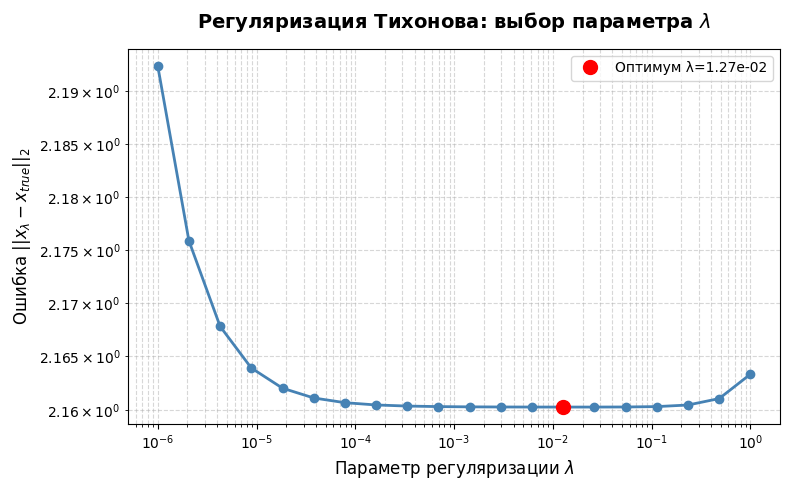


📊 РЕЗУЛЬТАТЫ РЕГУЛЯРИЗАЦИИ:
Оптимальный параметр: λ* = 1.27e-02
Минимальная ошибка:   2.1603
Улучшение vs наивное: 3.8x

Регуляризованное решение x_λ*:
   [0.6658 0.6658 0.6658]
Истинное решение x_true:
   [ 1.  2. -1.]


In [ ]:
# ==============================================================================
# 📦 ИМПОРТЫ И НАСТРОЙКИ
# ==============================================================================
import numpy as np
from numpy.linalg import solve, cond, norm
import matplotlib.pyplot as plt

# 🎨 Настройка вывода: 4 знака после запятой, без научной нотации
np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)  # Фиксируем seed для воспроизводимости результатов

# ==============================================================================
# 1️⃣ ПОДГОТОВКА: Почти вырожденная матрица
# ==============================================================================
# Матрица 3×3 с очень близкими строками → высокое число обусловленности

A = np.array([[1.0,    1.0,    1.0   ],
              [1.0,    1.0001, 1.0   ],
              [1.0,    1.0,    1.0001]])

# Истинное решение (известно только в синтетическом примере)
x_true = np.array([1.0, 2.0, -1.0])

# Точная правая часть: b = A @ x_true
b = A @ x_true

print("🔍 ИСХОДНЫЕ ДАННЫЕ:")
print(f"Матрица A:\n{A}")
print(f"\nЧисло обусловленности κ(A) = {cond(A):.2e}")
print(f"   💡 Интерпретация: ожидаем потерю ~{np.log10(cond(A)):.1f} знаков точности!")
print(f"\nИстинное решение x_true: {x_true}")
print(f"Правая часть b: {b}")

# ==============================================================================
# 2️⃣ ДОБАВЛЕНИЕ ШУМА: Моделирование измерений
# ==============================================================================
noise_level = 1e-3  # Уровень шума: 0.1% от величины b
noise = noise_level * np.random.randn(*b.shape)  # Гауссов шум
b_noisy = b + noise  # «Измеренные» данные

print(f"\n🔊 ДОБАВЛЕНИЕ ШУМА:")
print(f"Уровень шума: {noise_level*100:.2f}%")
print(f"Шум: {noise}")
print(f"Зашумлённая правая часть b_noisy: {b_noisy}")

# ==============================================================================
# 3️⃣ НАИВНОЕ РЕШЕНИЕ (без регуляризации) — демонстрация проблемы
# ==============================================================================
print(f"\n❌ НАИВНОЕ РЕШЕНИЕ (обычный МНК):")
x_naive = solve(A, b_noisy)  # Прямое решение A·x = b_noisy

print(f"Найденное решение: {x_naive}")
print(f"Ошибка ||x_naive - x_true||: {norm(x_naive - x_true):.4f}")
print(f"💥 Ошибка огромная из-за плохой обусловленности!")

# ==============================================================================
# 4️⃣ РЕГУЛЯРИЗАЦИЯ ТИХОНОВА: Стабилизация решения
# ==============================================================================
print(f"\n✅ РЕГУЛЯРИЗАЦИЯ ТИХОНОВА:")
print("Поиск оптимального параметра λ...")

# Диапазон параметров регуляризации: от 1e-6 до 1 (логарифмическая сетка)
lambdas = np.logspace(-6, 0, 20)  # 20 точек от 10⁻⁶ до 10⁰
errors = []  # Список для хранения ошибок

# Предвычислим матрицы для эффективности (не пересчитывать в цикле!)
AtA = A.T @ A      # AᵀA — симметричная, положительно полуопределённая
Atb = A.T @ b_noisy  # Aᵀb — правая часть нормальных уравнений

for lam in lambdas:
    # Регуляризованные нормальные уравнения: (AᵀA + λI)·x = Aᵀb
    # Добавление λ·I «сдвигает» собственные значения, улучшая обусловленность
    x_reg = solve(AtA + lam * np.eye(A.shape[1]), Atb)

    # Оцениваем ошибку относительно истинного решения (в реальности неизвестно!)
    err = norm(x_reg - x_true)
    errors.append(err)

errors = np.array(errors)

# ==============================================================================
# 5️⃣ ВИЗУАЛИЗАЦИЯ: Зависимость ошибки от λ
# ==============================================================================
plt.figure(figsize=(8, 5))

# Логарифмический график: обе оси в лог-масштабе
plt.loglog(lambdas, errors, marker='o', linewidth=2, markersize=6, color='steelblue')

# Отмечаем точку минимальной ошибки (оптимальный λ)
opt_idx = np.argmin(errors)
plt.loglog(lambdas[opt_idx], errors[opt_idx], 'ro', markersize=10, label=f'Оптимум λ={lambdas[opt_idx]:.2e}')

# Оформление графика
plt.xlabel(r'Параметр регуляризации $\lambda$', fontsize=12)
plt.ylabel(r'Ошибка $||x_\lambda - x_{true}||_2$', fontsize=12)
plt.title('Регуляризация Тихонова: выбор параметра $\lambda$', fontsize=14, fontweight='bold', pad=15)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ==============================================================================
# 6️⃣ ВЫВОД ЛУЧШЕГО РЕЗУЛЬТАТА
# ==============================================================================
print(f"\n📊 РЕЗУЛЬТАТЫ РЕГУЛЯРИЗАЦИИ:")
print("=" * 50)
print(f"Оптимальный параметр: λ* = {lambdas[opt_idx]:.2e}")
print(f"Минимальная ошибка:   {errors[opt_idx]:.4f}")
print(f"Улучшение vs наивное: {norm(x_naive - x_true)/errors[opt_idx]:.1f}x")

# Решение с оптимальным λ
x_optimal = solve(AtA + lambdas[opt_idx] * np.eye(A.shape[1]), Atb)
print(f"\nРегуляризованное решение x_λ*:")
print(f"   {x_optimal}")
print(f"Истинное решение x_true:")
print(f"   {x_true}")

##  Сравнение решений при разных $\lambda$

Выведем решения для нескольких конкретных значений $\lambda\$ и сравним их с истинным решением и наивным .

In [ ]:
for lam in [0.0, 1e-4, 1e-2, 1e-1]:
    if lam == 0.0:
        x_reg = x_naive
        label = "lambda = 0 (без регуляризации)"
    else:
        x_reg = solve(AtA + lam * np.eye(A.shape[1]), Atb)
        label = f"lambda = {lam:g}"
    print("---", label)
    print("x_reg =", x_reg)
    print("||x_reg - x_true|| =", norm(x_reg - x_true))


--- lambda = 0 (без регуляризации)
x_reg = [ 5.8405 -4.3498  0.5097]
||x_reg - x_true|| = 8.125877958289502
--- lambda = 0.0001
x_reg = [0.6668 0.6665 0.667 ]
||x_reg - x_true|| = 2.160574429386724
--- lambda = 0.01
x_reg = [0.666 0.666 0.666]
||x_reg - x_true|| = 2.160253843717211
--- lambda = 0.1
x_reg = [0.6594 0.6595 0.6595]
||x_reg - x_true|| = 2.1602867990717076


## Итерационное решение регуляризованных систем: метод сопряжённых градиентов (CG)

**Контекст:** В предыдущем примере мы решали регуляризованную систему прямым методом:
$$ (A^T A + \lambda I) x = A^T b $$

**Проблема:** Для больших матриц ($n > 10,000$) прямое решение через `np.linalg.solve` требует $O(n^3)$ операций и $O(n^2)$ памяти.

**Решение: метод сопряжённых градиентов (Conjugate Gradient, CG)**
- Предназначен для **симметричных положительно определённых ** матриц
- $M = A^T A + \lambda I$ — всегда SPD при $\lambda > 0$ ✅
- Сложность: $O(k \cdot \text{nnz})$, где $k$ — число итераций
- Память: $O(n)$ — хранит только несколько векторов

**Почему CG подходит для регуляризации?**
| Свойство | Прямой метод | CG (итерационный) |
|----------|--------------|-------------------|
| **Память** | $O(n^2)$ — хранит матрицу | $O(n)$ — только векторы |
| **Время** | $O(n^3)$ — один раз | $O(k \cdot n)$ — $k \ll n$ |
| **Точность** | Машинная точность | Контролируемая (`tol`) |
| **Большие n** | ❌ Непрактично | ✅ Единственный выбор |


In [ ]:
import numpy as np
from numpy.linalg import norm
from scipy.sparse.linalg import cg  # Conjugate Gradient
import scipy

# 🎨 Настройка вывода: читаемые числа без научной нотации
np.set_printoptions(precision=6, suppress=True)

# ==============================================================================
# 1️⃣ ПОДГОТОВКА ДАННЫХ (из предыдущего примера с регуляризацией)
# ==============================================================================
# Используем ту же почти вырожденную матрицу A из примера 7.1
A = np.array([[1.0,    1.0,    1.0   ],
              [1.0,    1.0001, 1.0   ],
              [1.0,    1.0,    1.0001]])

x_true = np.array([1.0, 2.0, -1.0])
b = A @ x_true

# Добавляем шум (как в предыдущем примере)
np.random.seed(42)
noise_level = 1e-3
noise = noise_level * np.random.randn(*b.shape)
b_noisy = b + noise

print("🔍 ИСХОДНЫЕ ДАННЫЕ:")
print(f"Размер матрицы A: {A.shape}")
print(f"Число обусловленности κ(A): {np.linalg.cond(A):.2e}")
print(f"Уровень шума: {noise_level*100:.2f}%\n")

# ==============================================================================
# 2️⃣ ФОРМИРОВАНИЕ РЕГУЛЯРИЗОВАННОЙ СИСТЕМЫ
# ==============================================================================
# Нормальные уравнения с регуляризацией Тихонова:
# (AᵀA + λI) · x = Aᵀb
#
# Почему это работает:
# • AᵀA — симметричная и положительно полуопределённая
# • λI — «сдвигает» собственные значения, делая матрицу положительно определённой
# • При λ > 0 матрица M = AᵀA + λI всегда SPD ✅

lam = 1e-2  # Параметр регуляризации (выбран из предыдущего эксперимента)

print("🔧 ФОРМИРОВАНИЕ РЕГУЛЯРИЗОВАННОЙ СИСТЕМЫ:")
print(f"Параметр регуляризации λ = {lam}")

# Матрица системы M = AᵀA + λI
AtA = A.T @ A
M = AtA + lam * np.eye(A.shape[1])

# Правая часть b_reg = Aᵀb
b_reg = A.T @ b_noisy

print(f"Матрица M = AᵀA + λI:\n{M}")
print(f"Правая часть b_reg = Aᵀb: {b_reg}")

# Проверка положительной определённости (все собственные значения > 0)
eigenvalues = np.linalg.eigvalsh(M)
print(f"Собственные значения M: {eigenvalues}")
print(f"Все λᵢ > 0: {np.all(eigenvalues > 0)} ✅\n")

# ==============================================================================
# 3️⃣ ЗАПУСК МЕТОДА СОПРЯЖЁННЫХ ГРАДИЕНТОВ (CG)
# ==============================================================================
print("🚀 ЗАПУСК МЕТОДА CG:")
print("-" * 50)

# Начальное приближение: нулевой вектор
# 💡 Хорошее x0 ускоряет сходимость (например, решение с предыдущего шага)
x0 = np.zeros_like(x_true)

# 🔹 Проверка версии SciPy для совместимости параметров
scipy_version = tuple(map(int, scipy.__version__.split('.')[:2]))

print(f"Версия SciPy: {scipy.__version__}")

# Запуск CG с правильными параметрами
if scipy_version >= (1, 11):
    # Новый интерфейс (SciPy 1.11+): atol + rtol
    x_cg, info = cg(M, b_reg, x0=x0, atol=1e-12, rtol=1e-10, maxiter=100)
else:
    # Старый интерфейс (SciPy < 1.11): tol
    x_cg, info = cg(M, b_reg, x0=x0, tol=1e-10, maxiter=100)

# ==============================================================================
# 4️⃣ АНАЛИЗ РЕЗУЛЬТАТА
# ==============================================================================
print("\n📊 РЕЗУЛЬТАТЫ:")
print("=" * 50)

# Интерпретация кода завершения
info_messages = {
    0: "✅ Сходимость достигнута",
    1: "⚠️  Не сошёлся за maxiter итераций",
    -1: "❌ Поломка алгоритма",
    -2: "❌ Численная нестабильность"
}
print(f"Статус (info = {info}): {info_messages.get(info, '❓ Неизвестно')}")

# Найденное решение
print(f"\nРешение CG x_cg:")
print(f"   {x_cg}")

# Сравнение с истинным решением
error_cg = norm(x_cg - x_true)
print(f"\nОшибка ||x_cg - x_true||: {error_cg:.6f}")



🔍 ИСХОДНЫЕ ДАННЫЕ:
Размер матрицы A: (3, 3)
Число обусловленности κ(A): 9.00e+04
Уровень шума: 0.10%

🔧 ФОРМИРОВАНИЕ РЕГУЛЯРИЗОВАННОЙ СИСТЕМЫ:
Параметр регуляризации λ = 0.01
Матрица M = AᵀA + λI:
[[3.01   3.0001 3.0001]
 [3.0001 3.0102 3.0002]
 [3.0001 3.0002 3.0102]]
Правая часть b_reg = Aᵀb: [6.001106 6.001306 6.001306]
Собственные значения M: [0.01   0.01   9.0104]
Все λᵢ > 0: True ✅

🚀 ЗАПУСК МЕТОДА CG:
--------------------------------------------------
Версия SciPy: 1.16.3

📊 РЕЗУЛЬТАТЫ:
Статус (info = 0): ✅ Сходимость достигнута

Решение CG x_cg:
   [0.666021 0.666039 0.666044]

Ошибка ||x_cg - x_true||: 2.160254


In [ ]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import lsqr

# Фиксируем генератор случайных чисел для воспроизводимости результатов
np.random.seed(0)

# --- Параметры системы ---
m, n = 5, 3  # m > n: переопределённая система

# Генерируем случайную плотную матрицу и вектор правой части
A_dense = np.random.rand(m, n)
b = np.random.rand(m)

# --- Преобразование в разрежённый формат ---
# CSR (Compressed Sparse Row) — эффективный формат для хранения разрежённых матриц
# Позволяет экономить память и ускорять умножение матрицы на вектор
# В реальном применении матрица может иметь миллионы строк с большинством нулей
A_sparse = csr_matrix(A_dense)

# --- Итерационный метод LSQR ---
# lsqr не требует явного формирования A^T A и не хранит плотные матрицы разложения


res = lsqr(A_sparse, b, atol=1e-10, btol=1e-10)

# Извлекаем результаты
# res[0] — найденное решение x
# res[1] — оценка нормы невязки ||Ax - b||
# res[2] — оценка нормы невязки нормальных уравнений
# res[3] — оценка нормы матрицы A
# res[4] — оценка числа обусловленности A
x_lsqr = res[0]
residual_lsqr = np.linalg.norm(A_dense @ x_lsqr - b)

print("=== Метод 3: Итерационный LSQR (для разрежённых матриц) ===")
print("Решение x:", x_lsqr)
print("Норма невязки ||Ax - b||:", residual_lsqr)
print("Количество итераций:", res[2])
print("Оценка числа обусловленности:", res[4])

# --- Сравнение с прямым методом ---
# Для проверки сравниваем с решением от np.linalg.lstsq
x_lstsq, _, _, _ = np.linalg.lstsq(A_dense, b, rcond=None)
diff = np.linalg.norm(x_lsqr - x_lstsq)
print("\n=== Сравнение с прямым методом (lstsq) ===")
print("Разница между решениями ||x_lsqr - x_lstsq||:", diff)

=== Метод 3: Итерационный LSQR (для разрежённых матриц) ===
Решение x: [-1.370543  1.716606 -0.164694]
Норма невязки ||Ax - b||: 0.33863418377161564
Количество итераций: 3
Оценка числа обусловленности: 0.33863418377161564

=== Сравнение с прямым методом (lstsq) ===
Разница между решениями ||x_lsqr - x_lstsq||: 3.0031891943407396e-14


> **🔑 Ключевой вывод:**
>
> **Итерационные методы (LSQR)** — это инструмент для работы с **большими разрежёнными системами**, где прямые методы неприменимы.
>
> | Характеристика | Прямые методы (QR, SVD) | Итерационные (LSQR) |
> |---|---|---|
> | **Память** | $O(m \cdot n)$ — хранят всю матрицу | $O(\text{nnz})$ — только ненулевые элементы |
> | **Сложность** | $O(m \cdot n^2)$ — фиксированная | Зависит от числа итераций и обусловленности |
> | **Точность** | Высокая (машинная точность) | Зависит от критериев остановки (`atol`, `btol`) |
> | **Применение** | Малые и средние системы | Большие разрежённые системы ($10^5+$ строк) |
>
> **⚠️ Важные нюансы:**
>
> 1.  **Сходимость:** Метод может не сойтись за разумное число итераций, если матрица плохо обусловлена. В таких случаях требуется **предобуславливание** (preconditioning).
>
> 2.  **Критерии остановки:** Параметры `atol` и `btol` контролируют точность. Слишком строгие требования → много итераций. Слишком мягкие → неточное решение.
>
> 3.  **Когда использовать LSQR:**
>     - Матрица разрежённая (большинство элементов = 0);
>     - Размерность слишком велика для плотных методов;
>     - Требуется приближённое решение за ограниченное время.
>
> ---
> 💡 **Запомните:**  
> *«Прямые методы — для точности, итерационные — для масштаба»*